In [1]:
import pandas as pd

band = 'w1'
var_list = pd.read_csv('/data/project_unTimely_light_curve/results/GMM_clustering/%.1f-%.1f_%s_co_above_0.6_var_table_new.csv'%(8.0,18.1,band))
print(len(var_list))

8618964


In [2]:
var_list['ra_block'] = [name[0:4] for name in var_list['long_name']]
var_list['dec_block'] = [name[4:8] for name in var_list['long_name']]
print(var_list)

         Unnamed: 0         ra        dec  id_in_matched long_name  id_w1  \
0                 0  80.032547  44.642123           7827  0790p439   7828   
1                 1  75.873531  31.161539          17114  0758p318  17115   
2                 2  74.474833  40.159720          32123  0751p408  32124   
3                 3  74.020499 -28.477773          29927  0737m288  29928   
4                 4  60.378884  55.045322          39028  0612p545  39029   
...             ...        ...        ...            ...       ...    ...   
8618959        2175  82.575170 -54.202841          40127  0817m546  40128   
8618960        2176  81.177994 -52.509797          37033  0813m531  37034   
8618961        2177  80.806787 -52.609029          41008  0813m531  41009   
8618962        2178  81.126698 -51.327834          45086  0810m515  45087   
8618963        2179  81.236830 -65.549210          19358  0803m652  19359   

         id_w2   distance ra_block dec_block  
0         7811  80.959406   

In [3]:
var_list = var_list.sort_values(by=['ra_block','dec_block'])
print(var_list)

         Unnamed: 0          ra        dec  id_in_matched long_name  id_w1  \
201883        20367    0.345989  -1.621361           5680  0000m016   5681   
640788        19973  359.556687  -1.990181          14883  0000m016  14884   
728801        19940    0.469511  -1.761498           4803  0000m016   4804   
1019729       23006    0.378607  -2.194626           9705  0000m016   9706   
1142383       25556  359.477952  -1.368634           3635  0000m016   3636   
...             ...         ...        ...            ...       ...    ...   
8213523      117644  358.142448  20.328858           2293  3584p196   2294   
8213524      117645  357.796752  19.961714           9011  3584p196   9012   
8213525      117646  357.909724  19.714246          13689  3584p196  13690   
8213526      117647  357.699039  19.071914          23173  3584p196  23174   
8213527      117648  358.526243  20.065954          27108  3584p196  27109   

         id_w2    distance ra_block dec_block  
201883    5496 

In [4]:
import numpy as np
n = 10
sliced_var_lists = np.array_split(var_list, n)

In [5]:
print(len(sliced_var_lists[0]))
print(sliced_var_lists[0])

861897
         Unnamed: 0          ra       dec  id_in_matched long_name  id_w1  \
201883        20367    0.345989 -1.621361           5680  0000m016   5681   
640788        19973  359.556687 -1.990181          14883  0000m016  14884   
728801        19940    0.469511 -1.761498           4803  0000m016   4804   
1019729       23006    0.378607 -2.194626           9705  0000m016   9706   
1142383       25556  359.477952 -1.368634           3635  0000m016   3636   
...             ...         ...       ...            ...       ...    ...   
5015347       56879   54.955385  2.824050          13908  0544p030  13909   
5015348       56880   54.272732  3.233148          14630  0544p030  14631   
5015349       56881   55.088942  3.692283          14853  0544p030  14854   
5015350       56882   54.194911  2.630949          25055  0544p030  25056   
5015351       56883   54.964580  2.747708          27673  0544p030  27674   

         id_w2    distance ra_block dec_block  
201883    5496  145.

In [10]:
from util import make_single_light_curve
import numpy as np
from astropy.timeseries import LombScargle
import pickle
import gc

def period_sigma_finding(target_list,index):
    i = 0
    best_period_list = []
    second_period_list = []
    best_fap_list = []
    second_fap_list = []
    sigma2_list = []
    ex_1_sigma2_list = []    
    ex_2_sigma2_list = []
    last_long_name = ''
    table1 = 'placeholder'
    while i < len(target_list):
        long_name = target_list.iloc[i]['long_name']
        id_in_matched = target_list.iloc[i]['id_in_matched']
        name = long_name[0:3]
        if long_name!= last_long_name:
            del table1
            gc.collect()
            table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
        last_long_name = long_name
        ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_in_matched))
        

        mag1 -= np.mean(mag1)
        ls = LombScargle(mjdmean1, mag1)
        freq,power = ls.autopower(minimum_frequency=1/1800, maximum_frequency=1/100)
        best_freq = freq[np.argmax(power)]
        best_period_list.append(1/best_freq)
        best_fap = ls.false_alarm_probability(power.max(),
                                            minimum_frequency=1/1800, maximum_frequency=1/100)
        best_fap_list.append(best_fap)

        power[np.argmax(power)]=-9999999
        second_freq = freq[np.argmax(power)]
        second_period_list.append(1/second_freq)
        second_fap = ls.false_alarm_probability(power.max(), 
                                            minimum_frequency=1/1800, maximum_frequency=1/100)
        second_fap_list.append(second_fap)
        
        # print(1/best_freq, 1/second_freq,best_fap,second_fap,i)
        # print(1/best_freq, 1/second_freq,i)

        sigma2 = np.square(np.std(mag1))
        ex_1_mag = np.array([elmt for j,elmt in enumerate(mag1) if j != np.argmax(mag1)])
        ex_1_sigma2 = np.square(np.std(ex_1_mag))
        ex_2_mag = np.array([elmt for j,elmt in enumerate(ex_1_mag) if j != np.argmin(ex_1_mag)])
        ex_2_sigma2 = np.square(np.std(ex_2_mag))
        sigma2_list.append(sigma2)
        ex_1_sigma2_list.append(ex_1_sigma2)
        ex_2_sigma2_list.append(ex_2_sigma2)

        # print(sigma2,ex_1_sigma2,ex_2_sigma2,i)

        last_counter = int(i/1000)
        i+=1
        if int(i/1000) > last_counter:
            print('%.2f percent done...for pice'%(i/len(target_list)*100),index)

    with open('./tmp_data/period_result%d.pkl'%index, 'wb') as f:
        pickle.dump([best_period_list, best_fap_list, second_period_list, second_fap_list], f)
    with open('./tmp_data/sigma_result%d.pkl'%index, 'wb') as f:
        pickle.dump([sigma2_list, ex_1_sigma2_list, ex_2_sigma2_list], f)
    return 

In [9]:
period_sigma_finding(target_list=var_list,index=0)

0.01 percent done...for pice 0
0.02 percent done...for pice 0
0.03 percent done...for pice 0
0.05 percent done...for pice 0


KeyboardInterrupt: 

In [11]:
from multiprocessing import Pool
thread_pool = Pool()
for i, target_list in enumerate(sliced_var_lists):
    if i < 10:
        thread_pool.apply_async(period_sigma_finding, args=(target_list,i))
thread_pool.close()
thread_pool.join()

0.12 percent done...for pice 0
0.12 percent done...for pice 2
0.12 percent done...for pice 1
0.12 percent done...for pice 3
0.12 percent done...for pice 5
0.12 percent done...for pice 4
0.23 percent done...for pice 0
0.12 percent done...for pice 6
0.23 percent done...for pice0.23 percent done...for pice  1
2
0.23 percent done...for pice 5
0.12 percent done...for pice 7
0.23 percent done...for pice 3
0.23 percent done...for pice 6
0.23 percent done...for pice 7
0.23 percent done...for pice 4
0.12 percent done...for pice 9
0.35 percent done...for pice 0
0.12 percent done...for pice 8
0.35 percent done...for pice 6
0.35 percent done...for pice 2
0.35 percent done...for pice 7
0.35 percent done...for pice 1
0.23 percent done...for pice 8
0.35 percent done...for pice 5
0.46 percent done...for pice 6
0.46 percent done...for pice 7
0.35 percent done...for pice 3
0.46 percent done...for pice 0
0.35 percent done...for pice 4
0.58 percent done...for pice 6
0.46 percent done...for pice 1
0.35 per

/tmp/ipykernel_2112913/3921503453.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')


6.61 percent done...for pice 6
5.92 percent done...for pice 0
5.11 percent done...for pice 1
4.99 percent done...for pice 2
6.73 percent done...for pice 7
7.19 percent done...for pice 8
6.03 percent done...for pice 0
7.31 percent done...for pice 8
5.11 percent done...for pice 9
4.52 percent done...for pice 3
5.11 percent done...for pice 4
6.15 percent done...for pice 0
7.43 percent done...for pice 8
5.69 percent done...for pice 5
6.27 percent done...for pice 0
5.22 percent done...for pice 1
6.38 percent done...for pice 0
6.73 percent done...for pice 6
7.54 percent done...for pice 8
6.85 percent done...for pice 7
6.50 percent done...for pice 0
5.11 percent done...for pice 2
5.80 percent done...for pice 5
6.61 percent done...for pice 0
4.64 percent done...for pice 3
6.85 percent done...for pice 6
6.96 percent done...for pice 7
7.66 percent done...for pice 8
5.22 percent done...for pice 4
5.22 percent done...for pice 9
6.96 percent done...for pice 6
6.73 percent done...for pice 0
7.77 per

/tmp/ipykernel_2112913/3921503453.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')


6.61 percent done...for pice 2
8.24 percent done...for pice 0
9.51 percent done...for pice 7
9.86 percent done...for pice 8
9.75 percent done...for pice 6
9.98 percent done...for pice 7.66 percent done...for pice8 
5
9.63 percent done...for pice 7
6.73 percent done...for pice 4
6.85 percent done...for pice 9
6.03 percent done...for pice 3
6.73 percent done...for pice 2
6.85 percent done...for pice 1
10.09 percent done...for pice 8
9.75 percent done...for pice 7
8.35 percent done...for pice 0
6.96 percent done...for pice 9
9.86 percent done...for pice 6
9.86 percent done...for pice 7
10.21 percent done...for pice 8
9.98 percent done...for pice 7
7.77 percent done...for pice 5
6.85 percent done...for pice 4
10.09 percent done...for pice 7
6.85 percent done...for pice
 26.96 percent done...for pice 1
6.15 percent done...for pice 3
9.98 percent done...for pice 6
8.47 percent done...for pice 0
10.33 percent done...for pice 8
6.96 percent done...for pice 4
10.21 percent done...for pice 7
10.

...

96.65 percent done...for pice 2
88.29 percent done...for pice 0
95.26 percent done...for pice 1
89.11 percent done...for pice 3
88.41 percent done...for pice 0
88.76 percent done...for pice 9
96.76 percent done...for pice 2
95.37 percent done...for pice 1
89.22 percent done...for pice 3
88.53 percent done...for pice 0
88.87 percent done...for pice 9
96.88 percent done...for pice 2
95.49 percent done...for pice 1
89.34 percent done...for pice 3
88.64 percent done...for pice 0
88.99 percent done...for pice 9
95.60 percent done...for pice 1
97.00 percent done...for pice 2
95.72 percent done...for pice 1
88.76 percent done...for pice 0
89.45 percent done...for pice 3
89.11 percent done...for pice 9
97.11 percent done...for pice 2
95.84 percent done...for pice 1
88.87 percent done...for pice 0
89.57 percent done...for pice 3
89.22 percent done...for pice 9
97.23 percent done...for pice 2
95.95 percent done...for pice 1
89.69 percent done...for pice 3
88.99 percent done...for pice 0
89.34 pe

/tmp/ipykernel_2112913/3921503453.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')


92.12 percent done...for pice 98.39 percent done...for pice3 
1
99.55 percent done...for pice 2
91.54 percent done...for pice 9
91.31 percent done...for pice 0
98.50 percent done...for pice 1
92.24 percent done...for pice 3
99.66 percent done...for pice 2
91.66 percent done...for pice 9
91.43 percent done...for pice 0
98.62 percent done...for pice 1
99.78 percent done...for pice 2
92.35 percent done...for pice 3
91.77 percent done...for pice 9
91.54 percent done...for pice 0
98.74 percent done...for pice 1
99.90 percent done...for pice 2
92.47 percent done...for pice 3
91.66 percent done...for pice 0
91.89 percent done...for pice 9
92.59 percent done...for pice 3
92.01 percent done...for pice 9
98.85 percent done...for pice 1
91.77 percent done...for pice 0
92.70 percent done...for pice 3
98.97 percent done...for pice 1
92.82 percent done...for pice 3
92.12 percent done...for pice 9
91.89 percent done...for pice 0
99.08 percent done...for pice 1
92.93 percent done...for pice 3
92.01 pe

/tmp/ipykernel_2112913/3921503453.py:25: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')


97.11 percent done...for pice 3
96.07 percent done...for pice 9
96.18 percent done...for pice 0
97.23 percent done...for pice 3
96.18 percent done...for pice 9
96.30 percent done...for pice 0
96.42 percent done...for pice 0
97.34 percent done...for pice 3
96.30 percent done...for pice 9
96.53 percent done...for pice 0
97.46 percent done...for pice 3
96.42 percent done...for pice 9
96.65 percent done...for pice 0
97.58 percent done...for pice 3
96.53 percent done...for pice 9
96.76 percent done...for pice 0
97.69 percent done...for pice 3
96.88 percent done...for pice 0
96.65 percent done...for pice 9
97.81 percent done...for pice 3
97.00 percent done...for pice 0
96.76 percent done...for pice 9
97.92 percent done...for pice 3
97.11 percent done...for pice 0
98.04 percent done...for pice 3
96.88 percent done...for pice 9
97.23 percent done...for pice 0
98.16 percent done...for pice 3
97.00 percent done...for pice 9
97.11 percent done...for pice 9
97.34 percent done...for pice 0
98.27 pe

In [12]:
best_period_list = []
best_fap_list = []
second_period_list = []
second_fap_list = []
sigma2_list = []
ex_1_sigma2_list = []
ex_2_sigma2_list = []

for i in range(0,10):
    best_period_list_i, best_fap_list_i, second_period_list_i, second_fap_list_i = pickle.load(open('./tmp_data/period_result%d.pkl'%i, "rb"))
    best_period_list+=best_period_list_i
    best_fap_list+=best_fap_list_i
    second_period_list+=second_period_list_i
    second_fap_list+=second_fap_list_i
    sigma2_list_i, ex_1_sigma2_list_i, ex_2_sigma2_list_i = pickle.load(open('./tmp_data/sigma_result%d.pkl'%i, "rb"))
    sigma2_list+=sigma2_list_i
    ex_1_sigma2_list+=ex_1_sigma2_list_i
    ex_2_sigma2_list+=ex_2_sigma2_list_i

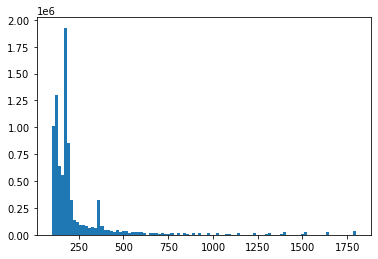

In [15]:
from matplotlib import pyplot as plt
plt.hist(best_period_list,bins=100)
plt.show()

In [29]:
effective_best_period_list = [period for i, period in enumerate(best_period_list) if best_fap_list[i]<0.05]
print(len(effective_best_period_list))
effective_second_period_list = [period for i, period in enumerate(second_period_list) if second_fap_list[i]<0.05]
print(len(effective_second_period_list))

1097730
860620


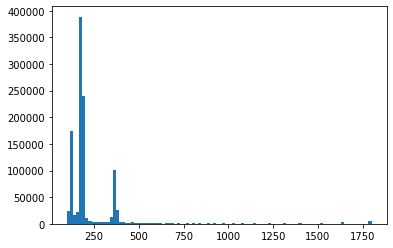

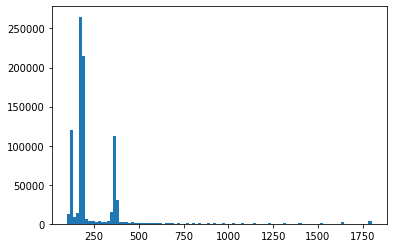

In [30]:
plt.hist(effective_best_period_list,bins=100)
plt.show()
plt.hist(effective_second_period_list,bins=100)
plt.show()

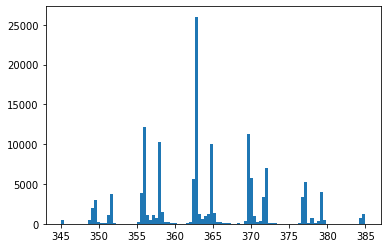

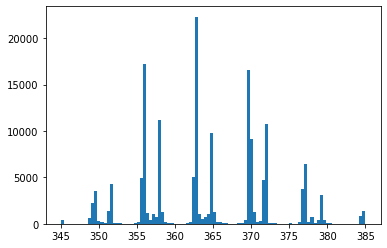

In [32]:
plt.hist(effective_best_period_list,bins=100,range=(345,385))
plt.show()
plt.hist(effective_second_period_list,bins=100,range=(345,385))
plt.show()

In [56]:
best_period_exclude_list = [i for i,period in enumerate(best_period_list)
                            if best_fap_list[i]<0.05 and period>345 and period<385]
second_period_exclude_list = [i for i,period in enumerate(second_period_list)
                             if second_fap_list[i]<0.05 and period>345 and period<385]


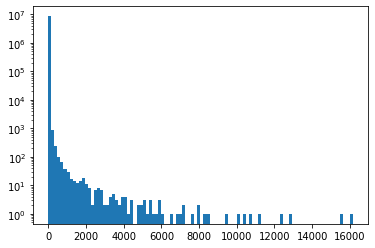

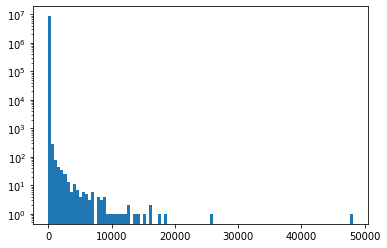

In [36]:
from matplotlib import pyplot as plt
plt.hist(np.divide(sigma2_list,ex_1_sigma2_list),bins=100,log=True)
plt.show()
plt.hist(np.divide(sigma2_list,ex_2_sigma2_list),bins=100,log=True)
plt.show()

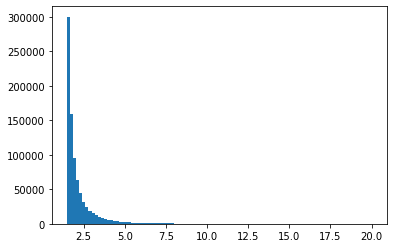

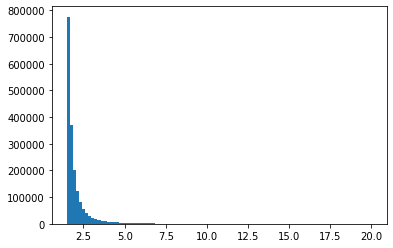

In [37]:
plt.hist(np.sqrt(np.divide(sigma2_list,ex_1_sigma2_list)),bins=100,range=(1.5,20))
plt.show()
plt.hist(np.sqrt(np.divide(sigma2_list,ex_2_sigma2_list)),bins=100,range=(1.5,20))
plt.show()

In [39]:
ex1 = np.divide(sigma2_list,ex_1_sigma2_list)
ex2 = np.divide(sigma2_list,ex_2_sigma2_list)
sigma2_excluded_list = [i for i,simga2 in enumerate(sigma2_list) if (ex1[i]>10 and ex2[i]>10)]
print(len(sigma2_excluded_list))

33177


In [54]:
import numpy as np
from matplotlib import pyplot as plt    

result_list = []
for i in range(0,10000):
    t = np.linspace(0,16,16)
    base_signal = 0.00001 * np.sin(2 * np.pi * t/16)
    # base_signal = t*0.125
    y = base_signal + np.random.normal(0,0.1,len(t))
    j = np.random.randint(0,len(t))
    y[j]+=1.75
    sigma2 = np.square(np.std(y))
    ex_1_mag = np.array([elmt for j,elmt in enumerate(y) if j != np.argmax(y)])
    ex_1_sigma2 = np.square(np.std(ex_1_mag))
    result_list.append(sigma2/ex_1_sigma2)
    

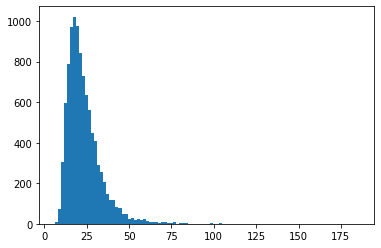

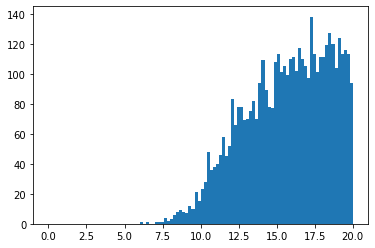

In [55]:
plt.hist(result_list,bins=100)
plt.show()
plt.hist(result_list,bins=100,range=(0,20))
plt.show()

1.2624896079146355 1.4650964175002277
358.5475512 , -75.6609306 358.5475512 -75.6609306


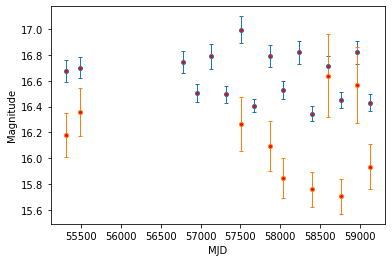

In [57]:
from IPython.display import clear_output
target_list = var_list
while i < len(target_list):
    # if ex1[i]>20 or ex2[i]>20:
    if i in best_period_exclude_list:
        clear_output(wait=True)

        print(ex1[i],ex2[i])
        # ra,dec = target_list.iloc[i]['ra'],target_list.iloc[i]['dec']
        # print(ra,dec)
        long_name = target_list.iloc[i]['long_name']
        id_in_matched = target_list.iloc[i]['id_in_matched']
        # target_id = target_list.iloc[i]['TARGETID']
        id_w1 = target_list.iloc[i]['id_w1']
        id_w2 = target_list.iloc[i]['id_w2']
        name = long_name[0:3]
        table1 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w1_mached.csv')
        table2 = pd.read_csv('./mached_catalog/'+name+'/'+long_name+'/'+long_name+'_w2_mached.csv')
        ra1,dec1,mag1,error1,mjdmean1 = make_single_light_curve(table1,int(id_w1-1))
        ra2,dec2,mag2,error2,mjdmean2 = make_single_light_curve(table2,int(id_w2-1))
        # df1 = pd.DataFrame({'mag':mag1,'error':error1,'mjdmean':mjdmean1})
        # df2 = pd.DataFrame({'mag':mag2,'error':error2,'mjdmean':mjdmean2})
        # df1.to_csv('./tmp_data/w1/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
        # df2.to_csv('./tmp_data/w2/'+str(target_id)+'_'+str(ra)+'_'+str(dec)+'.csv',index=False)
        # i += np.random.randint(1,20)
        i+=1
        print(ra1,',',dec1,ra2,dec2)
        plt.xlabel('MJD')
        plt.ylabel('Magnitude')
        plt.errorbar(mjdmean1,mag1,error1,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
        plt.errorbar(mjdmean2,mag2,error2,fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
        plt.show()
        user_input = input('Do you want to continue? (y/n)')
        if user_input == 'n':
            break
    else:
        i+=1
        continue